## Task 2 — Exploratory Data Analysis (EDA)

In [9]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1) Load the dataset

Update `DATA_PATH` to the location of your XLS/XLSX/CSV file before running the notebook.

In [2]:
DATA_PATH = Path("../data/raw/data.csv")  # Change this to your actual file path

def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {path}. Update DATA_PATH to the correct file location."
        )

    suffix = path.suffix.lower()
    if suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    elif suffix == ".csv":
        df = pd.read_csv(path)
    else:
        raise ValueError(
            f"Unsupported file type: {suffix}. Use .csv, .xls, or .xlsx."
        )

    return df

df = load_data(DATA_PATH)
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,"1,000.0000",1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0000,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0000,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,"20,000.0000",21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0000,644,2018-11-15T03:34:21Z,2,0


## 2) Overview of the data
Inspect the structure, shape, and data types.

In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print()

display(df.info())

print(" First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

Rows: 95,662
Columns: 16

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64 

None

 First 5 rows:


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,"1,000.0000",1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0000,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0000,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,"20,000.0000",21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0000,644,2018-11-15T03:34:21Z,2,0


Last 5 rows:


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
95657,TransactionId_89881,BatchId_96668,AccountId_4841,SubscriptionId_3829,CustomerId_3078,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,"-1,000.0000",1000,2019-02-13T09:54:09Z,2,0
95658,TransactionId_91597,BatchId_3503,AccountId_3439,SubscriptionId_2643,CustomerId_3874,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,"1,000.0000",1000,2019-02-13T09:54:25Z,2,0
95659,TransactionId_82501,BatchId_118602,AccountId_4841,SubscriptionId_3829,CustomerId_3874,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0000,20,2019-02-13T09:54:35Z,2,0
95660,TransactionId_136354,BatchId_70924,AccountId_1346,SubscriptionId_652,CustomerId_1709,UGX,256,ProviderId_6,ProductId_19,tv,ChannelId_3,"3,000.0000",3000,2019-02-13T10:01:10Z,2,0
95661,TransactionId_35670,BatchId_29317,AccountId_4841,SubscriptionId_3829,CustomerId_1709,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-60.0000,60,2019-02-13T10:01:28Z,2,0


In [5]:
# Check unique counts for high-cardinality identifier columns
id_columns = ["TransactionId", "BatchId", "AccountId", "SubscriptionId", "CustomerId"]
available_id_columns = [c for c in id_columns if c in df.columns]

unique_counts = pd.DataFrame({
    "column": available_id_columns,
    "unique_values": [df[c].nunique(dropna=False) for c in available_id_columns]
})
unique_counts

,column,unique_values
0,TransactionId,95662
1,BatchId,94809
2,AccountId,3633
3,SubscriptionId,3627
4,CustomerId,3742


## 3) Data types and basic cleaning checks
Convert the timestamp column to datetime and confirm whether the values parsed correctly.

In [6]:
# Convert timestamp column
if "TransactionStartTime" in df.columns:
    df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"], errors="coerce", utc=True)

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

print("Missing timestamps after conversion:", df["TransactionStartTime"].isna().sum() if "TransactionStartTime" in df.columns else "N/A")

Numeric columns: ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']
Categorical columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId']
Missing timestamps after conversion: 0


## 4) Summary statistics
Assess central tendency, dispersion, and the shape of the numerical variables.

In [8]:
display(df.describe(include=[np.number]).T)

print("Categorical summary:")
display(df.describe(include=["object"]).T)

if "TransactionStartTime" in df.columns:
    print("Timestamp range:")
    print("Min:", df["TransactionStartTime"].min())
    print("Max:", df["TransactionStartTime"].max())

,count,mean,std,min,25%,50%,75%,max
CountryCode,"95,662.0000",256.0000,0.0000,256.0000,256.0000,256.0000,256.0000,256.0000
Amount,"95,662.0000","6,717.8464","123,306.7972","-1,000,000.0000",-50.0000,"1,000.0000","2,800.0000","9,880,000.0000"
Value,"95,662.0000","9,900.5839","123,122.0878",2.0000,275.0000,"1,000.0000","5,000.0000","9,880,000.0000"
PricingStrategy,"95,662.0000",2.2560,0.7329,0.0000,2.0000,2.0000,2.0000,4.0000
FraudResult,"95,662.0000",0.0020,0.0449,0.0000,0.0000,0.0000,0.0000,1.0000


Categorical summary:


,count,unique,top,freq
TransactionId,95662,95662,TransactionId_76871,1
BatchId,95662,94809,BatchId_67019,28
AccountId,95662,3633,AccountId_4841,30893
SubscriptionId,95662,3627,SubscriptionId_3829,32630
CustomerId,95662,3742,CustomerId_7343,4091
CurrencyCode,95662,1,UGX,95662
ProviderId,95662,6,ProviderId_4,38189
ProductId,95662,23,ProductId_6,32635
ProductCategory,95662,9,financial_services,45405
ChannelId,95662,4,ChannelId_3,56935


Timestamp range:
Min: 2018-11-15 02:18:49+00:00
Max: 2019-02-13 10:01:28+00:00


## 5) Distribution of numerical features
The following histograms help identify skewness, concentration, and possible extreme values.

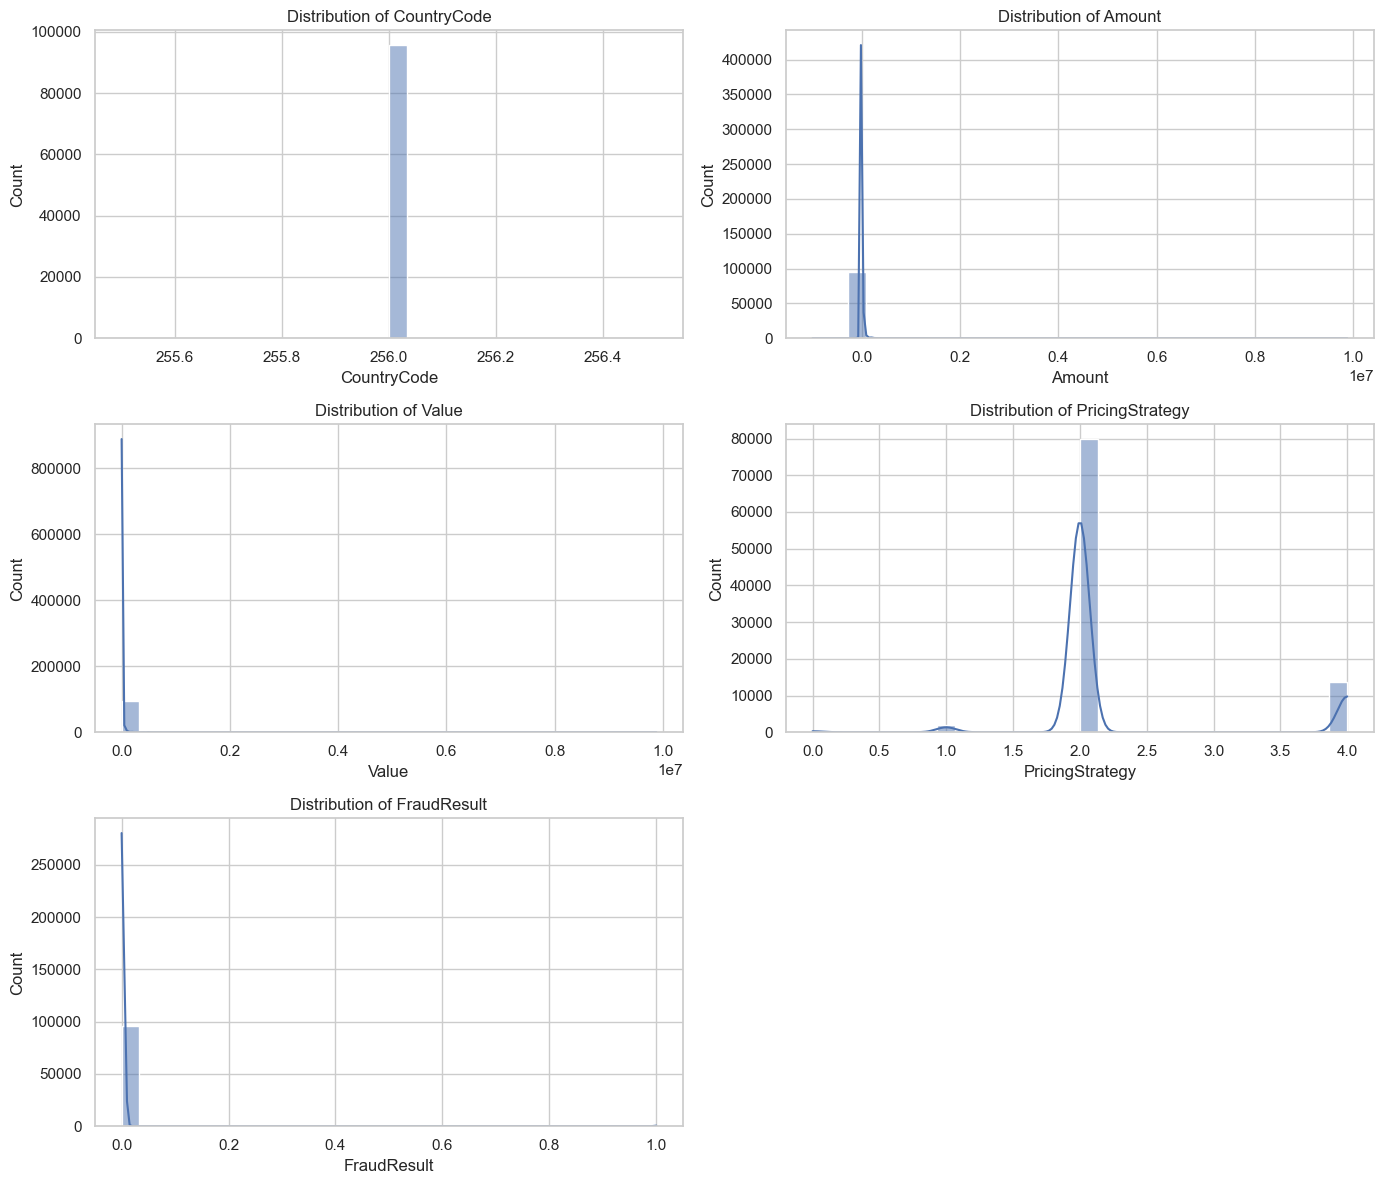

In [10]:
num_cols_for_plots = numeric_cols.copy()

# Create a grid of histograms
n_cols = 2
n_rows = math.ceil(len(num_cols_for_plots) / n_cols) if num_cols_for_plots else 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols_for_plots):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6) Distribution of categorical features
For high-cardinality columns, the notebook shows the top 10 most frequent categories to keep the plots readable.

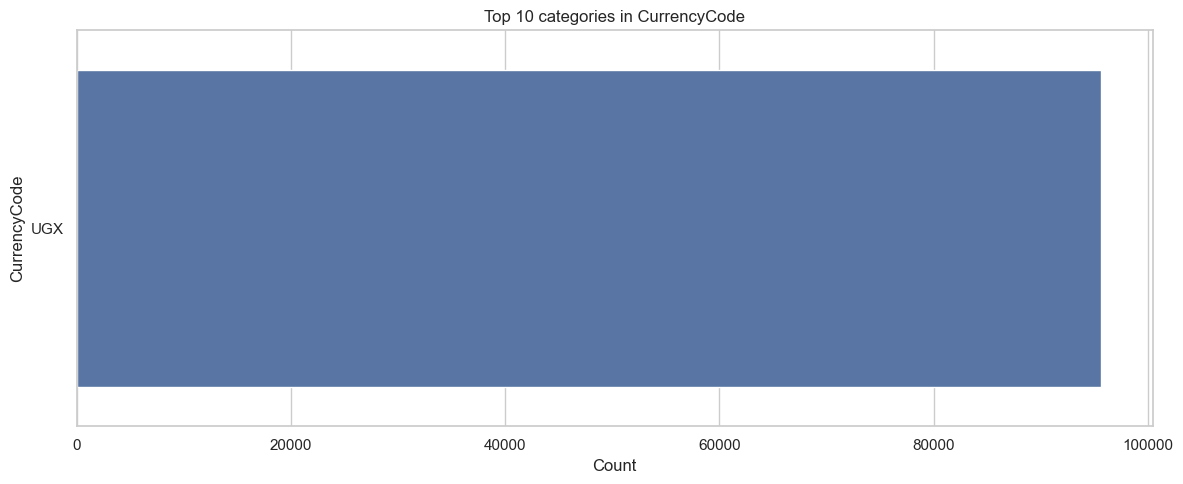

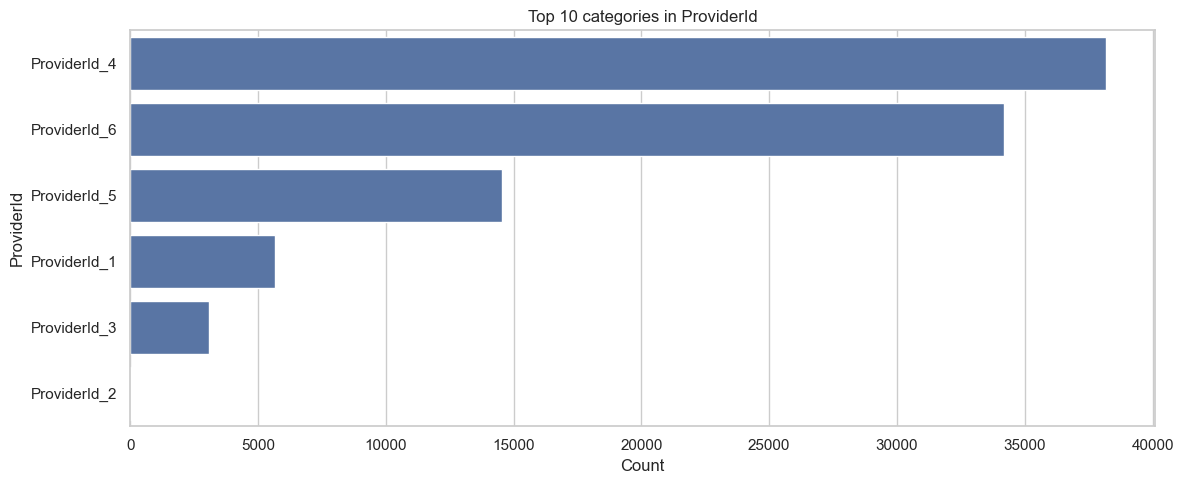

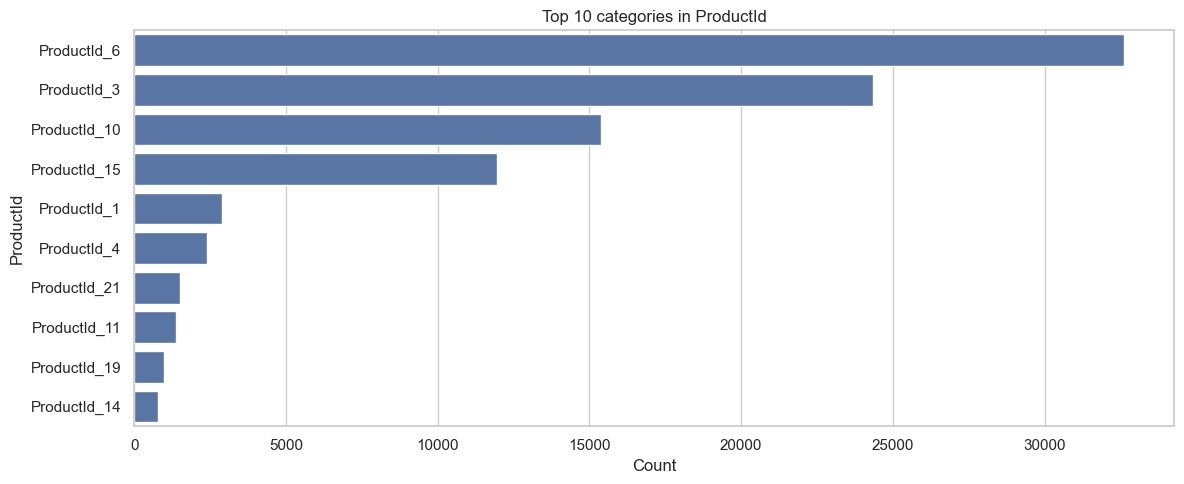

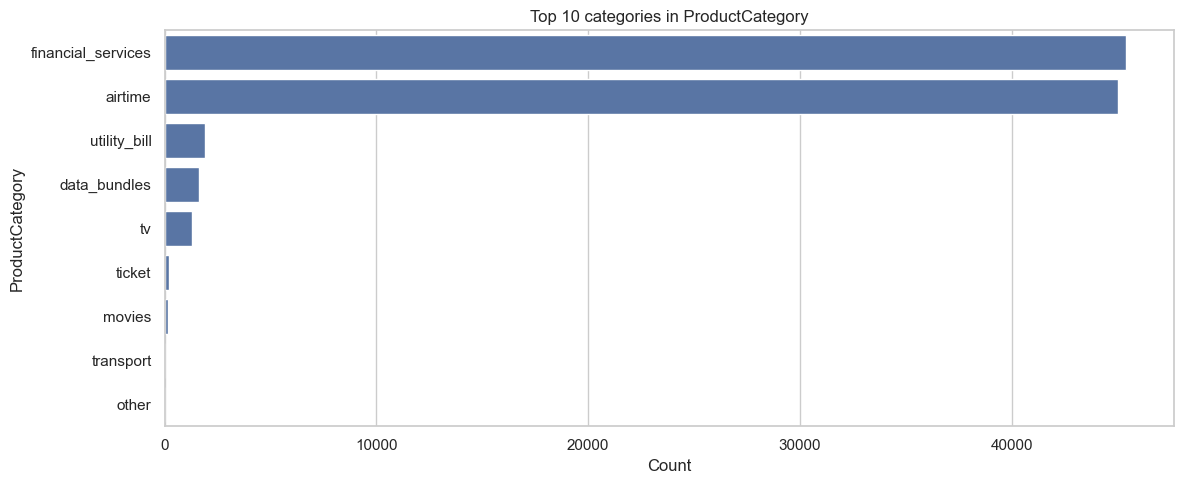

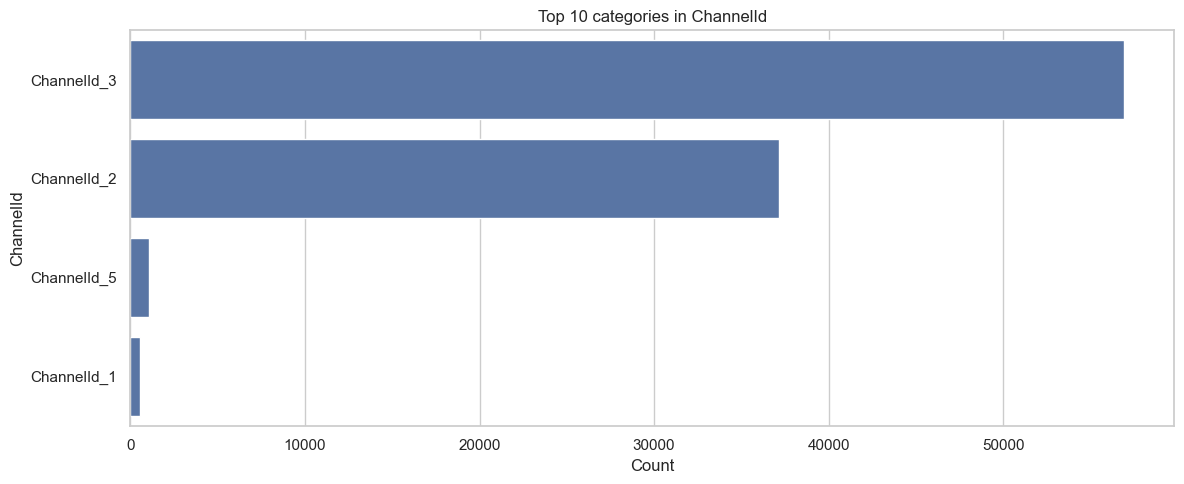

In [11]:
# Exclude very high-cardinality identifiers from full categorical plots
high_cardinality_ids = {"TransactionId", "BatchId", "AccountId", "SubscriptionId", "CustomerId"}
cat_cols_for_plots = [c for c in categorical_cols if c not in high_cardinality_ids]

def plot_top_categories(data: pd.DataFrame, column: str, top_n: int = 10):
    plt.figure(figsize=(12, 5))
    order = data[column].value_counts(dropna=False).head(top_n).index
    sns.countplot(
        data=data,
        y=column,
        order=order
    )
    plt.title(f"Top {top_n} categories in {column}")
    plt.xlabel("Count")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

for col in cat_cols_for_plots:
    plot_top_categories(df, col, top_n=10)

## 7) Correlation analysis
Use a correlation heatmap to understand relationships among numerical variables.

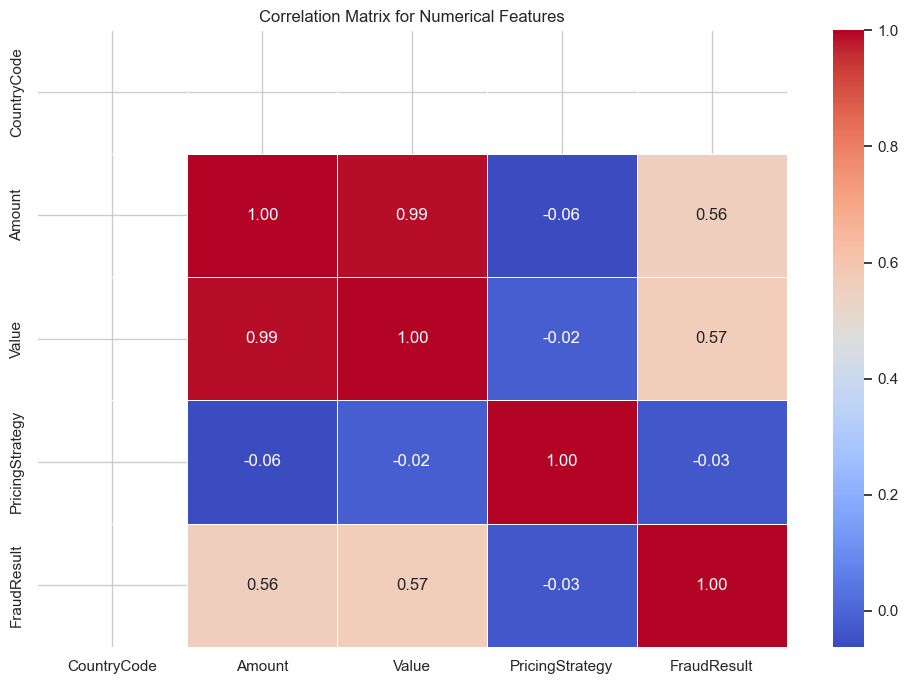

Top correlations by absolute value:


correlation
Amount          Value                 0.9897
Value           FraudResult           0.5667
Amount          FraudResult           0.5574
                PricingStrategy      -0.0619
PricingStrategy FraudResult          -0.0338
Value           PricingStrategy      -0.0170

In [12]:
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 7))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
    plt.title("Correlation Matrix for Numerical Features")
    plt.tight_layout()
    plt.show()

    # Show strongest pairwise correlations
    corr_pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    print("Top correlations by absolute value:")
    display(corr_pairs.to_frame(name="correlation").head(10))
else:
    print("Not enough numeric columns for correlation analysis.")

## 8) Identifying missing values
Check the number and percentage of missing values in each column.

In [16]:
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_table = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

display(missing_table)

,missing_count,missing_percent
TransactionId,0,0.0000
BatchId,0,0.0000
AccountId,0,0.0000
SubscriptionId,0,0.0000
CustomerId,0,0.0000
CurrencyCode,0,0.0000
CountryCode,0,0.0000
ProviderId,0,0.0000
ProductId,0,0.0000
ProductCategory,0,0.0000


## 9) Outlier detection
Use box plots to inspect extreme values in numerical columns.

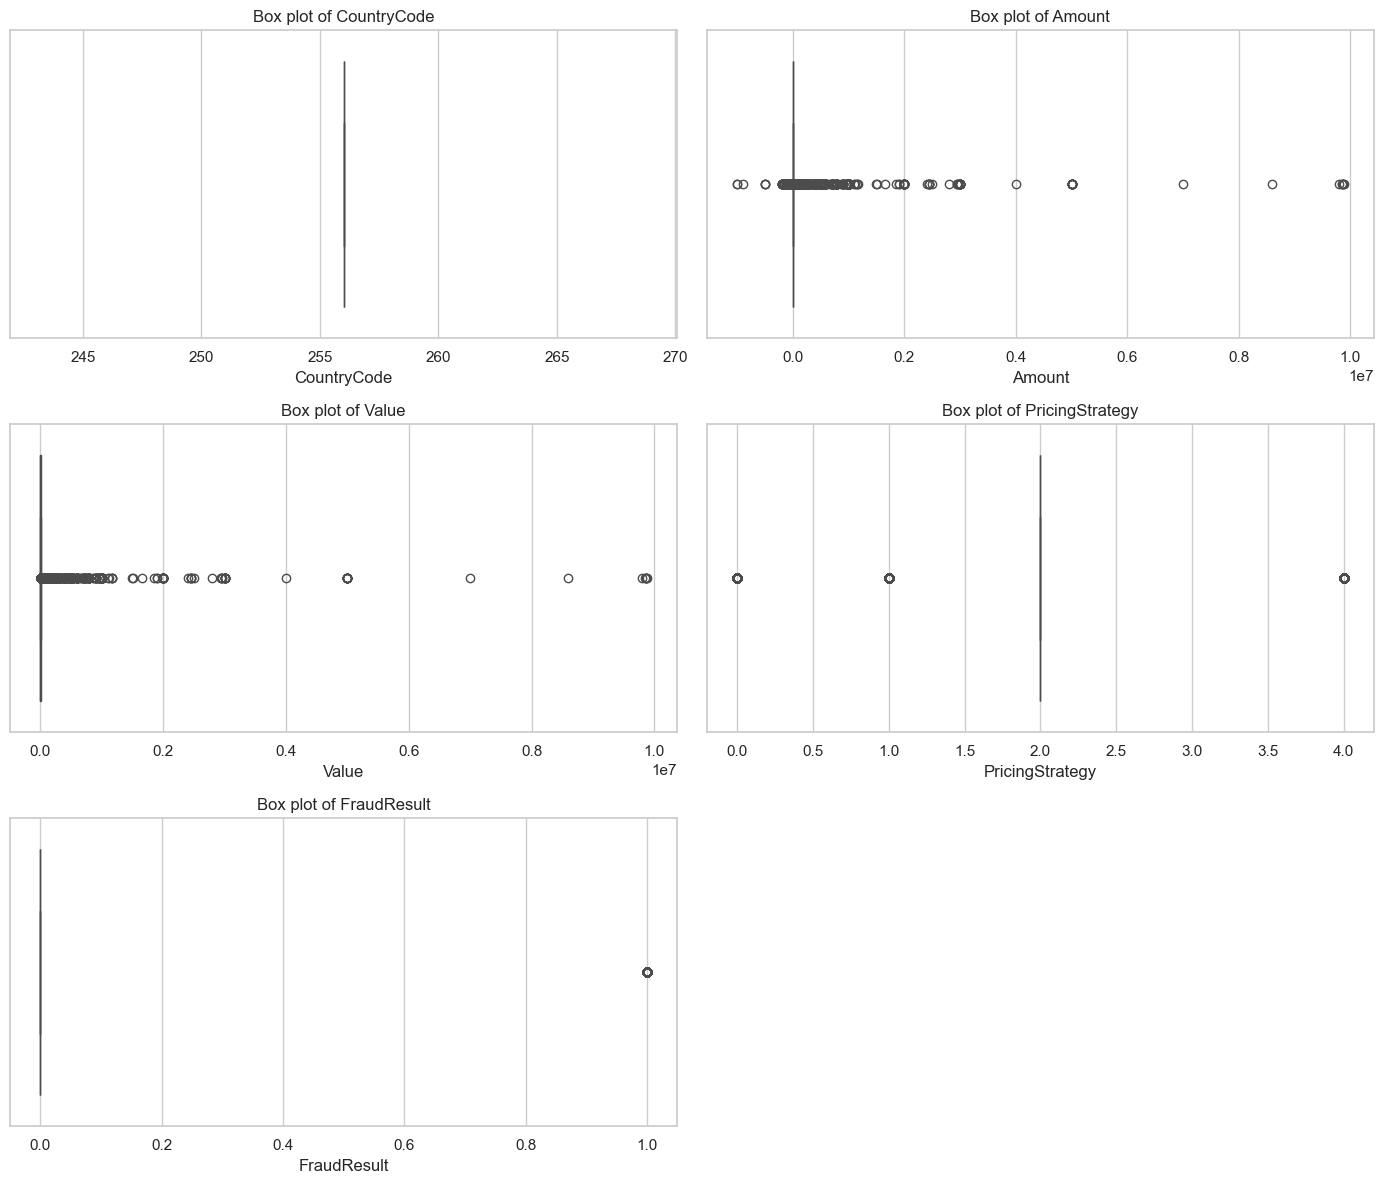

In [14]:
# Box plots for numeric variables
if numeric_cols:
    n_cols = 2
    n_rows = math.ceil(len(numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_cols):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f"Box plot of {col}")
        axes[i].set_xlabel(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found for box plots.")

## 10) Save data

In [15]:
df.to_csv('../data/raw/data_cleaned.csv', index=False)

## Top EDA Insights Summary

### 1. The Dataset is Large, Clean, and Suitable for Credit Risk Modeling

The dataset contains **95,662 transaction records** and **16 features**, providing a strong foundation for building behavioral credit scoring models. Importantly, there are **no missing values** across any column, including timestamps, which reduces preprocessing complexity and improves data reliability. The dataset also spans transactions from **November 2018 to February 2019**, enabling temporal behavioral analysis such as Recency, Frequency, and Monetary (RFM) feature engineering.

---

### 2. Transaction Amounts are Highly Skewed with Significant Outliers

The `Amount` and `Value` variables exhibit strong positive skewness and extreme outliers. Although the median transaction amount is only **1,000 UGX**, the maximum transaction reaches nearly **9.88 million UGX**, while the minimum is **-1 million UGX**. Additionally, the standard deviation is extremely high relative to the mean, indicating large variability in customer transaction behavior. These findings suggest that:

* robust scaling or log transformations may be necessary,
* outlier handling will be important,
* and transaction size could become a strong predictor of credit risk.

---

### 3. Customer Activity is Highly Concentrated Among a Small Group of Users

The analysis reveals strong customer concentration patterns:

* `AccountId_4841` alone accounts for over **30,000 transactions**,
* `SubscriptionId_3829` appears more than **32,000 times**,
* and `financial_services` is the dominant product category with **45,405 transactions**.

This indicates that a relatively small subset of customers drives a large share of platform activity. Such behavioral concentration is important for credit modeling because highly active users may demonstrate different repayment risk profiles compared to infrequent users.

---

### 4. Fraud Cases are Extremely Rare, Creating a Highly Imbalanced Dataset

The `FraudResult` mean is approximately **0.002**, meaning fraudulent transactions represent only about **0.2%** of the dataset. This severe class imbalance is a critical modeling consideration because standard machine learning algorithms may become biased toward the majority non-fraud class. Future modeling stages may therefore require:

* stratified sampling,
* class weighting,
* resampling techniques such as SMOTE,
* or evaluation metrics beyond accuracy, such as F1-score, ROC-AUC, and Precision-Recall curves.

---

### 5. Transaction Value has a Strong Relationship with Fraud

Correlation analysis shows that `Value` and `Amount` are highly correlated (**0.9897**), which is expected because `Value` represents the absolute transaction amount. More importantly, both variables show relatively strong positive correlations with `FraudResult`:

* `Value` ↔ `FraudResult`: **0.5667**
* `Amount` ↔ `FraudResult`: **0.5574**

This suggests that unusually large transactions may be associated with higher fraud risk and could become highly informative predictive features in the credit scoring pipeline. However, because `Amount` and `Value` are nearly redundant, feature selection or dimensionality reduction may be necessary to avoid multicollinearity in interpretable models such as Logistic Regression.
